In [1]:
import geopandas as gpd

layers = gpd.read_file(r"Areas-of-interest-POIs\regionalverband_area.gpkg")

regions_list = layers['NAME'].unique()[1:]
print(regions_list)

['Braunschweig' 'Salzgitter' 'Wolfsburg' 'Gifhorn' 'Goslar' 'Helmstedt'
 'Peine' 'Wolfenbüttel']


In [2]:
import fiona

layers = fiona.listlayers(r"Areas-of-interest-POIs\bs_area_correct.gpkg")

gdf = gpd.read_file(
    r"Areas-of-interest-POIs\bs_area_correct.gpkg",
    layer=layers[1]  # second layer
)

region_gdfs = {}

for region in regions_list:
    region_gdfs[region] = gdf[gdf["RO_LANDK~1"] == region].copy()
    
    print(f"{region}: {len(region_gdfs[region])} rows")

Braunschweig: 212 rows
Salzgitter: 65 rows
Wolfsburg: 118 rows
Gifhorn: 119 rows
Goslar: 70 rows
Helmstedt: 137 rows
Peine: 78 rows
Wolfenbüttel: 81 rows


In [3]:
gdf = region_gdfs['Wolfenbüttel'] # Change to other region for other region analysis!
gdf.head()

,NO,CODE,NAME,TYPENO,RO_LANDK~1,SG_0_EW_~2,SG_1_EW_~3,SG_1_STU~4,SG_2_EWT~5,SG_2_EWT~6,...,SG_6_BE~20,SG_6_BE~21,SG_6_FR~22,SG_6_FR~23,SG_6_FR~24,SG_6_GE~25,SG_6_PR~26,SG_6_SONST,SG_7_AN~27,geometry
798,315800201,0,Baddeckenstedt 01,3,Wolfenbüttel,3991,3069.00,60.02,406.56,1019.44,...,15.0,0.0,32.0,762.0,730.0,4.0,14.0,0.0,38.0,"MULTIPOLYGON (((580799.025 5772920.092, 580797..."
799,315800401,0,Burgdorf 01,3,Wolfenbüttel,2605,2248.00,51.50,321.95,807.29,...,14.0,0.0,55.0,450.0,395.0,0.0,2.0,0.0,0.0,"MULTIPOLYGON (((581767.459 5780437.676, 581701..."
800,315800501,0,Cramme 01,3,Wolfenbüttel,882,858.00,18.75,130.39,326.96,...,3.0,0.0,25.0,120.0,95.0,0.0,2.0,0.0,0.0,"MULTIPOLYGON (((597978.225 5774883.939, 598066..."
801,315800601,0,Cremlingen 01,3,Wolfenbüttel,1946,79.87,1.46,11.60,29.07,...,4.0,0.0,5.0,275.0,270.0,3.0,10.0,0.0,0.0,"MULTIPOLYGON (((613175.077 5790775.719, 613232..."
802,315800602,0,Cremlingen 02,3,Wolfenbüttel,2560,2295.76,42.08,333.31,835.76,...,3.0,0.0,10.0,214.0,204.0,1.0,4.0,0.0,80.0,"MULTIPOLYGON (((614535.109 5795662.668, 614784..."


In [4]:
gdf['Education_School'] = gdf['SG_4_BS'] + gdf['SG_4_GSCH'] + gdf['SG_4_WFSCH']

gdf = gdf.rename(columns={
    'SG_3_BE~17': 'Workers',
    'SG_4_HS': 'University_Students',
    'SG_4_KITA': 'Kindergarten',
    'SG_5_EK~18': 'Shopping_Total',
    'SG_5_EK~19': 'Shopping_NonEssential',
    'SG_5_EK_TB': 'Shopping_DailyNeeds',
    'SG_6_FR~23': 'Leisure'
})

columns_to_keep = [
    'NAME',
    'Workers',
    'Education_School',
    'University_Students',
    'Kindergarten',
    'Shopping_Total',
    'Shopping_NonEssential',
    'Shopping_DailyNeeds',
    'Leisure',
    'geometry'
]

gdf = gdf[columns_to_keep]

gdf.head()

,NAME,Workers,Education_School,University_Students,Kindergarten,Shopping_Total,Shopping_NonEssential,Shopping_DailyNeeds,Leisure,geometry
798,Baddeckenstedt 01,922.23,207.0,0.0,100,6689.0,3522,3167,762.0,"MULTIPOLYGON (((580799.025 5772920.092, 580797..."
799,Burgdorf 01,356.66,64.0,0.0,63,659.0,625,34,450.0,"MULTIPOLYGON (((581767.459 5780437.676, 581701..."
800,Cramme 01,23.87,77.0,0.0,0,27.0,12,15,120.0,"MULTIPOLYGON (((597978.225 5774883.939, 598066..."
801,Cremlingen 01,1866.04,0.0,0.0,52,7168.0,1731,5437,275.0,"MULTIPOLYGON (((613175.077 5790775.719, 613232..."
802,Cremlingen 02,264.50,170.0,0.0,52,22.0,0,22,214.0,"MULTIPOLYGON (((614535.109 5795662.668, 614784..."


In [5]:
gdf = gdf.rename(columns={"NAME": "Region_Name", "Education_School": "School", "University_Students": "University", "Shopping_NonEssential": "Retail_Non-Daily", "Shopping_DailyNeeds": "Retail_Daily"})
gdf.head()

,Region_Name,Workers,School,University,Kindergarten,Shopping_Total,Retail_Non-Daily,Retail_Daily,Leisure,geometry
798,Baddeckenstedt 01,922.23,207.0,0.0,100,6689.0,3522,3167,762.0,"MULTIPOLYGON (((580799.025 5772920.092, 580797..."
799,Burgdorf 01,356.66,64.0,0.0,63,659.0,625,34,450.0,"MULTIPOLYGON (((581767.459 5780437.676, 581701..."
800,Cramme 01,23.87,77.0,0.0,0,27.0,12,15,120.0,"MULTIPOLYGON (((597978.225 5774883.939, 598066..."
801,Cremlingen 01,1866.04,0.0,0.0,52,7168.0,1731,5437,275.0,"MULTIPOLYGON (((613175.077 5790775.719, 613232..."
802,Cremlingen 02,264.50,170.0,0.0,52,22.0,0,22,214.0,"MULTIPOLYGON (((614535.109 5795662.668, 614784..."


In [6]:
df = gpd.read_file(r"Areas-of-interest-POIs\final_potentials_calculation.gpkg")
df.head()

,gml_id,volume_m3,osm_names,bosserhof_class,mid_label,potentials,geometry
0,13,89.209230,None,normal office,['work'],258.71,MULTIPOLYGON Z (((608781.076 5797034.372 86.80...
1,14,119.566130,None,normal office,['work'],346.74,"MULTIPOLYGON Z (((609122.06 5797462.983 85.46,..."
2,15,1033.650498,None,normal office,['work'],2997.59,MULTIPOLYGON Z (((609428.62 5797079.031 79.962...
3,16,46.560366,None,normal office,['work'],135.03,"MULTIPOLYGON Z (((609661.688 5797071.969 77.4,..."
4,0,931.423451,None,normal office,['work'],2701.13,MULTIPOLYGON Z (((609554.181 5797264.172 78.94...


In [7]:
import re
import pandas as pd
import numpy as np

valid_labels = [
    "Workers",
    "University",
    "School",
    "Kindergarten",
    "Retail_Daily",
    "Retail_Non-Daily",
    "Leisure",
]

label_map = {
    "work": "Workers",
    "business": "Workers",
    "university": "University",
    "school": "School",
    "childcare": "Kindergarten",
    "retail_daily": "Retail_Daily",
    "retail_non_daily": "Retail_Non-Daily",
    "errands": "Retail_Daily", # errands can be considered daily retail, but this is not true in all cases (public offices, banks, etc. need to decide about this)
    "leisure": "Leisure",
    "sports": "Leisure",
    "meetup": "Leisure",
    "lessons": "Leisure",
}

pattern = re.compile("|".join(sorted(map(re.escape, label_map.keys()), key=len, reverse=True)))


def clean_mid_label(x):
    if x is None:
        return []

    if isinstance(x, float) and pd.isna(x):
        return []

    if isinstance(x, (list, tuple, set, np.ndarray)):
        raw_labels = [str(v).strip() for v in x]
    else:
        raw_labels = pattern.findall(str(x))

    mapped = [label_map[label] for label in raw_labels if label in label_map]

    # remove duplicates, keep order
    return list(dict.fromkeys(mapped))


df["mid_label"] = df["mid_label"].apply(clean_mid_label)

In [8]:
df.head()

,gml_id,volume_m3,osm_names,bosserhof_class,mid_label,potentials,geometry
0,13,89.209230,None,normal office,[Workers],258.71,MULTIPOLYGON Z (((608781.076 5797034.372 86.80...
1,14,119.566130,None,normal office,[Workers],346.74,"MULTIPOLYGON Z (((609122.06 5797462.983 85.46,..."
2,15,1033.650498,None,normal office,[Workers],2997.59,MULTIPOLYGON Z (((609428.62 5797079.031 79.962...
3,16,46.560366,None,normal office,[Workers],135.03,"MULTIPOLYGON Z (((609661.688 5797071.969 77.4,..."
4,0,931.423451,None,normal office,[Workers],2701.13,MULTIPOLYGON Z (((609554.181 5797264.172 78.94...


In [9]:
import geopandas as gpd

# height dataset
height_gdf = gpd.read_file(
    r"Areas-of-interest-POIs\Enriched-building-volume-data.gpkg"
)

# make sure df is GeoDataFrame
df = gpd.GeoDataFrame(df, geometry="geometry", crs=height_gdf.crs)

# make CRS same
if df.crs != height_gdf.crs:
    height_gdf = height_gdf.to_crs(df.crs)

# keep only needed columns
height_gdf = height_gdf[["measHeight", "geometry"]].copy()

# convert height polygons to representative points
# representative_point is safer than centroid because it always lies inside polygon
height_points = height_gdf.copy()
height_points["geometry"] = height_points.geometry.representative_point()

# spatial join: find which df polygon contains each height point
matched = gpd.sjoin(
    df.reset_index().rename(columns={"index": "df_index"}),
    height_points[["measHeight", "geometry"]],
    how="left",
    predicate="contains"
)

# if multiple height points fall in one df polygon, keep first non-null measHeight
height_by_df = (
    matched
    .dropna(subset=["measHeight"])
    .groupby("df_index")["measHeight"]
    .first()
)

# add measHeight back to df
df["measHeight"] = df.index.map(height_by_df)

In [10]:
df = df.drop(columns=["volume_m3", "potentials"],axis=1)

df["area_m2"] = df.geometry.area

In [11]:
df['measHeight'].isna().sum()

1947

In [12]:
df['measHeight'] = df['measHeight'].fillna(3.5)

In [13]:
import numpy as np

# input assumption
DEFAULT_FLOOR_HEIGHT = 3.5  # meters

# calculate number of floors
# minimum 1 floor if measHeight is available but less than 3.5
df["num_floors"] = np.ceil(df["measHeight"] / DEFAULT_FLOOR_HEIGHT)

# handle missing height: assume 1 floor
df["num_floors"] = df["num_floors"].fillna(1)

# make sure floor count is at least 1
df["num_floors"] = df["num_floors"].clip(lower=1).astype(int)

# calculate total internal floor area
df["total_floor_area_m2"] = df["area_m2"] * df["num_floors"]

df.head()

,gml_id,osm_names,bosserhof_class,mid_label,geometry,measHeight,area_m2,num_floors,total_floor_area_m2
0,13,None,normal office,[Workers],MULTIPOLYGON Z (((608781.076 5797034.372 86.80...,4.137,21.563749,2,43.127498
1,14,None,normal office,[Workers],"MULTIPOLYGON Z (((609122.06 5797462.983 85.46,...",2.513,47.579041,1,47.579041
2,15,None,normal office,[Workers],MULTIPOLYGON Z (((609428.62 5797079.031 79.962...,2.769,424.386382,1,424.386382
3,16,None,normal office,[Workers],"MULTIPOLYGON Z (((609661.688 5797071.969 77.4,...",2.869,16.228778,1,16.228778
4,0,None,normal office,[Workers],MULTIPOLYGON Z (((609554.181 5797264.172 78.94...,4.377,212.799509,2,425.599018


In [14]:
df = df[
    [
        "gml_id",
        "osm_names",
        "bosserhof_class",
        "mid_label",
        "measHeight",
        "num_floors",
        "area_m2",
        "total_floor_area_m2",
        "geometry",
    ]
]
df.head()

,gml_id,osm_names,bosserhof_class,mid_label,measHeight,num_floors,area_m2,total_floor_area_m2,geometry
0,13,None,normal office,[Workers],4.137,2,21.563749,43.127498,MULTIPOLYGON Z (((608781.076 5797034.372 86.80...
1,14,None,normal office,[Workers],2.513,1,47.579041,47.579041,"MULTIPOLYGON Z (((609122.06 5797462.983 85.46,..."
2,15,None,normal office,[Workers],2.769,1,424.386382,424.386382,MULTIPOLYGON Z (((609428.62 5797079.031 79.962...
3,16,None,normal office,[Workers],2.869,1,16.228778,16.228778,"MULTIPOLYGON Z (((609661.688 5797071.969 77.4,..."
4,0,None,normal office,[Workers],4.377,2,212.799509,425.599018,MULTIPOLYGON Z (((609554.181 5797264.172 78.94...


In [15]:
# df.to_file(r"Areas-of-interest-POIs\Braunschweig-distribution-analysis\output-test.gpkg", driver="GPKG")

In [16]:
# -----------------------------
# 1. Define subcategory rates
# values are workers per 100 m²
# -----------------------------

worker_rate_per_100m2 = {
    # transport
    "transport": 0.5,
    "yards depots storage areas construction yards": (0.7 + 1.0) / 2,

    # industrial operations production
    "highly productive industries": (0.7 + 1.0) / 2,
    "others": (1.7 + 2.0) / 2,

    # crafts and trades
    "craft businesses": (1.3 + 2.5) / 2,
    "craft courtyards": (1.7 + 2.0) / 2,

    # services
    "normal office": (2.5 + 3.3) / 2,
    "open plan office": (3.3 + 5.0) / 2,
    "business oriented services": (2.0 + 5.0) / 2,
    "customer oriented services": (2.0 + 4.0) / 2,
    "hotels": (1.0 + 2.0) / 2,
    "hotels with conference areas": (0.7 + 0.9) / 2,
    "restaurants gastronomy": (1.3 + 2.5) / 2,
    "suppliers for car dealerships": 1.7,
    "vehicle electrical repair": (1.7 + 2.3) / 2,
    "customer service": 3.3,
    "car dealerships": 0.7,

    # retail
    "wholesale": (2.0 + 2.9) / 2,
    "retail small scale": (2.5 + 5.0) / 2,
    "discount stores": (0.7 + 1.1) / 2,
    "diy stores": (0.7 + 0.8) / 2,
    "furniture stores": (0.4 + 0.7) / 2,
    "hypermarkets superstores": (1.0 + 1.4) / 2,
    "shopping centers": (2.2 + 4.0) / 2,
    "self service department stores": (1.0 + 1.2) / 2,
    "department stores": (1.3 + 1.8) / 2,
    "factory outlet centers": (1.8 + 2.5) / 2,

    # public facilities
    "schools": (0.5 + 1.5) / 2,
    "universities": (0.5 + 1.0) / 2,
    "research institutes": (1.0 + 1.5) / 2,
    "kindergartens": (1.7 + 2.9) / 2,
    "hospitals": (1.0 + 1.5) / 2,

    # facilities for culture leisure and sports
    "entertainment culture": 1.67,
    "large cinemas": 0.83,
    "musical theatres": 1.43,
    "fitness wellness": 0.8,
}

# -----------------------------
# 2. Define main sections
# -----------------------------

section_to_categories = {
    "industrial operations production": [
        "highly productive industries",
        "others",
    ],
    "crafts and trades": [
        "craft businesses",
        "craft courtyards",
    ],
    "services": [
        "normal office",
        "open plan office",
        "business oriented services",
        "customer oriented services",
        "hotels",
        "hotels with conference areas",
        "restaurants gastronomy",
        "suppliers for car dealerships",
        "vehicle electrical repair",
        "customer service",
        "car dealerships",
    ],
    "retail": [
        "wholesale",
        "retail small scale",
        "discount stores",
        "diy stores",
        "furniture stores",
        "hypermarkets superstores",
        "shopping centers",
        "self service department stores",
        "department stores",
        "factory outlet centers",
    ],
    "public facilities": [
        "schools",
        "universities",
        "research institutes",
        "kindergartens",
        "hospitals",
    ],
    "facilities for culture leisure and sports": [
        "entertainment culture",
        "large cinemas",
        "musical theatres",
        "fitness wellness",
    ],
}

# -----------------------------
# 3. Add main section mean values
# -----------------------------

for section, categories in section_to_categories.items():
    worker_rate_per_100m2[section] = np.mean(
        [worker_rate_per_100m2[c] for c in categories]
    )

# -----------------------------
# 4. Add missing culture/leisure/sports categories
# using section average
# -----------------------------

culture_section_mean = worker_rate_per_100m2[
    "facilities for culture leisure and sports"
]

worker_rate_per_100m2["large discos fun leisure pools"] = culture_section_mean
worker_rate_per_100m2["arenas large events"] = culture_section_mean
worker_rate_per_100m2["theme parks"] = culture_section_mean

# -----------------------------
# 5. Clean bosserhof_class and assign rate
# -----------------------------

df["bosserhof_class_clean"] = (
    df["bosserhof_class"]
    .astype(str)
    .str.lower()
    .str.strip()
)

df["workers_per_100m2"] = df["bosserhof_class_clean"].map(worker_rate_per_100m2)

# -----------------------------
# 6. Check whether mid_label contains Workers
# -----------------------------

df["has_worker_label"] = df["mid_label"].apply(
    lambda x: "workers" in str(x).lower()
)

# -----------------------------
# 7. Calculate estimated workers
# -----------------------------

df["estimated_workers"] = np.where(
    df["has_worker_label"] & df["workers_per_100m2"].notna(),
    df["total_floor_area_m2"] / 100 * df["workers_per_100m2"],
    0
)

df["estimated_workers"] = df["estimated_workers"].round(2)

# -----------------------------
# 8. Check result
# -----------------------------

df[
    [
        "gml_id",
        "osm_names",
        "bosserhof_class",
        "mid_label",
        "total_floor_area_m2",
        # "workers_per_100m2",
        "estimated_workers",
        "geometry"
    ]
].head()

,gml_id,osm_names,bosserhof_class,mid_label,total_floor_area_m2,estimated_workers,geometry
0,13,None,normal office,[Workers],43.127498,1.25,MULTIPOLYGON Z (((608781.076 5797034.372 86.80...
1,14,None,normal office,[Workers],47.579041,1.38,"MULTIPOLYGON Z (((609122.06 5797462.983 85.46,..."
2,15,None,normal office,[Workers],424.386382,12.31,MULTIPOLYGON Z (((609428.62 5797079.031 79.962...
3,16,None,normal office,[Workers],16.228778,0.47,"MULTIPOLYGON Z (((609661.688 5797071.969 77.4,..."
4,0,None,normal office,[Workers],425.599018,12.34,MULTIPOLYGON Z (((609554.181 5797264.172 78.94...


In [17]:
gdf.head()

,Region_Name,Workers,School,University,Kindergarten,Shopping_Total,Retail_Non-Daily,Retail_Daily,Leisure,geometry
798,Baddeckenstedt 01,922.23,207.0,0.0,100,6689.0,3522,3167,762.0,"MULTIPOLYGON (((580799.025 5772920.092, 580797..."
799,Burgdorf 01,356.66,64.0,0.0,63,659.0,625,34,450.0,"MULTIPOLYGON (((581767.459 5780437.676, 581701..."
800,Cramme 01,23.87,77.0,0.0,0,27.0,12,15,120.0,"MULTIPOLYGON (((597978.225 5774883.939, 598066..."
801,Cremlingen 01,1866.04,0.0,0.0,52,7168.0,1731,5437,275.0,"MULTIPOLYGON (((613175.077 5790775.719, 613232..."
802,Cremlingen 02,264.50,170.0,0.0,52,22.0,0,22,214.0,"MULTIPOLYGON (((614535.109 5795662.668, 614784..."


In [18]:
# make sure both are GeoDataFrames
df = gpd.GeoDataFrame(df, geometry="geometry")
gdf = gpd.GeoDataFrame(gdf, geometry="geometry")

# make CRS same
if df.crs != gdf.crs:
    df = df.to_crs(gdf.crs)

# give TAZs a stable ID
gdf = gdf.reset_index().rename(columns={"index": "taz_id"})

# use representative point of building, safer for assigning each building to one TAZ
building_points = df.copy()
building_points["geometry"] = building_points.geometry.representative_point()

# spatial join: assign each building point to a TAZ
building_taz = gpd.sjoin(
    building_points[["estimated_workers", "geometry"]],
    gdf[["taz_id", "Region_Name", "geometry"]],
    how="left",
    predicate="within"
)

# sum estimated workers per TAZ
workers_by_taz = (
    building_taz
    .groupby("taz_id")["estimated_workers"]
    .sum()
    .reset_index(name="estimated_workers_taz")
)

# merge result back to gdf
gdf = gdf.merge(workers_by_taz, on="taz_id", how="left")

# replace missing with 0
gdf["estimated_workers_taz"] = gdf["estimated_workers_taz"].fillna(0)

In [19]:
gdf = gdf[["Region_Name","Workers","estimated_workers_taz","geometry"]]
gdf.head()

,Region_Name,Workers,estimated_workers_taz,geometry
0,Baddeckenstedt 01,922.23,5023.50,"MULTIPOLYGON (((580799.025 5772920.092, 580797..."
1,Burgdorf 01,356.66,3630.85,"MULTIPOLYGON (((581767.459 5780437.676, 581701..."
2,Cramme 01,23.87,1355.87,"MULTIPOLYGON (((597978.225 5774883.939, 598066..."
3,Cremlingen 01,1866.04,888.95,"MULTIPOLYGON (((613175.077 5790775.719, 613232..."
4,Cremlingen 02,264.50,2073.09,"MULTIPOLYGON (((614535.109 5795662.668, 614784..."


In [20]:
# calculate relative share of total workers

gdf["Workers_share"] = (
    gdf["Workers"] /
    gdf["Workers"].sum()
)

gdf["estimated_workers_share"] = (
    gdf["estimated_workers_taz"] /
    gdf["estimated_workers_taz"].sum()
)

gdf.head()

,Region_Name,Workers,estimated_workers_taz,geometry,Workers_share,estimated_workers_share
0,Baddeckenstedt 01,922.23,5023.50,"MULTIPOLYGON (((580799.025 5772920.092, 580797...",0.025405,0.032073
1,Burgdorf 01,356.66,3630.85,"MULTIPOLYGON (((581767.459 5780437.676, 581701...",0.009825,0.023182
2,Cramme 01,23.87,1355.87,"MULTIPOLYGON (((597978.225 5774883.939, 598066...",0.000658,0.008657
3,Cremlingen 01,1866.04,888.95,"MULTIPOLYGON (((613175.077 5790775.719, 613232...",0.051405,0.005676
4,Cremlingen 02,264.50,2073.09,"MULTIPOLYGON (((614535.109 5795662.668, 614784...",0.007286,0.013236


In [21]:
# gdf.to_file(r"Areas-of-interest-POIs\Braunschweig-distribution-analysis\Visum-clipped-braunschweig-with-estimated-workers.gpkg", driver="GPKG")

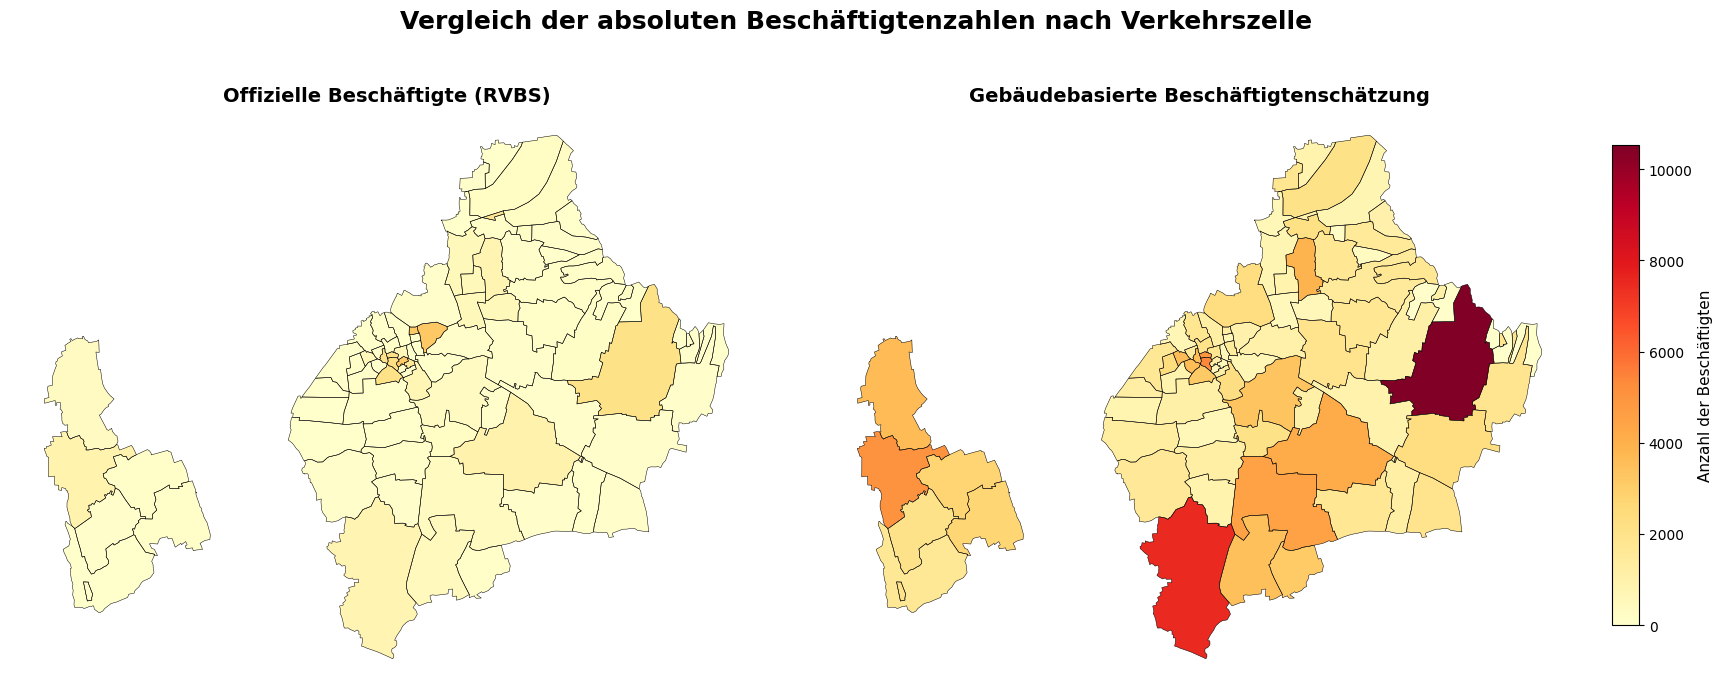

In [22]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# -----------------------------
# Gemeinsame Farbskala
# -----------------------------
vmin = min(
    gdf["Workers"].min(),
    gdf["estimated_workers_taz"].min()
)

vmax = max(
    gdf["Workers"].max(),
    gdf["estimated_workers_taz"].max()
)

# -----------------------------
# Abbildung
# -----------------------------
fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 8)
)

# -----------------------------
# Offizielle Beschäftigte
# -----------------------------
gdf.plot(
    column="Workers",
    cmap="YlOrRd",
    vmin=vmin,
    vmax=vmax,
    linewidth=0,
    edgecolor="none",
    ax=axes[0],
    legend=False
)

gdf.boundary.plot(
    ax=axes[0],
    color="black",
    linewidth=0.35
)

axes[0].set_title(
    "Offizielle Beschäftigte (RVBS)",
    fontsize=14,
    fontweight="bold"
)
axes[0].axis("off")

# -----------------------------
# Geschätzte Beschäftigte
# -----------------------------
gdf.plot(
    column="estimated_workers_taz",
    cmap="YlOrRd",
    vmin=vmin,
    vmax=vmax,
    linewidth=0,
    edgecolor="none",
    ax=axes[1],
    legend=False
)

gdf.boundary.plot(
    ax=axes[1],
    color="black",
    linewidth=0.35
)

axes[1].set_title(
    "Gebäudebasierte Beschäftigtenschätzung",
    fontsize=14,
    fontweight="bold"
)
axes[1].axis("off")

# -----------------------------
# Gemeinsame Farbskala
# -----------------------------
sm = ScalarMappable(
    norm=Normalize(vmin=vmin, vmax=vmax),
    cmap="YlOrRd"
)
sm.set_array([])

cax = fig.add_axes([0.92, 0.18, 0.015, 0.60])

cbar = fig.colorbar(
    sm,
    cax=cax
)

cbar.set_label(
    "Anzahl der Beschäftigten",
    fontsize=11
)

# -----------------------------
# Haupttitel
# -----------------------------
fig.suptitle(
    "Vergleich der absoluten Beschäftigtenzahlen nach Verkehrszelle",
    fontsize=18,
    fontweight="bold",
    y=0.95
)

# -----------------------------
# Abstand
# -----------------------------
plt.subplots_adjust(
    left=0.03,
    right=0.90,
    top=0.88,
    bottom=0.05,
    wspace=0.08
)

plt.show()

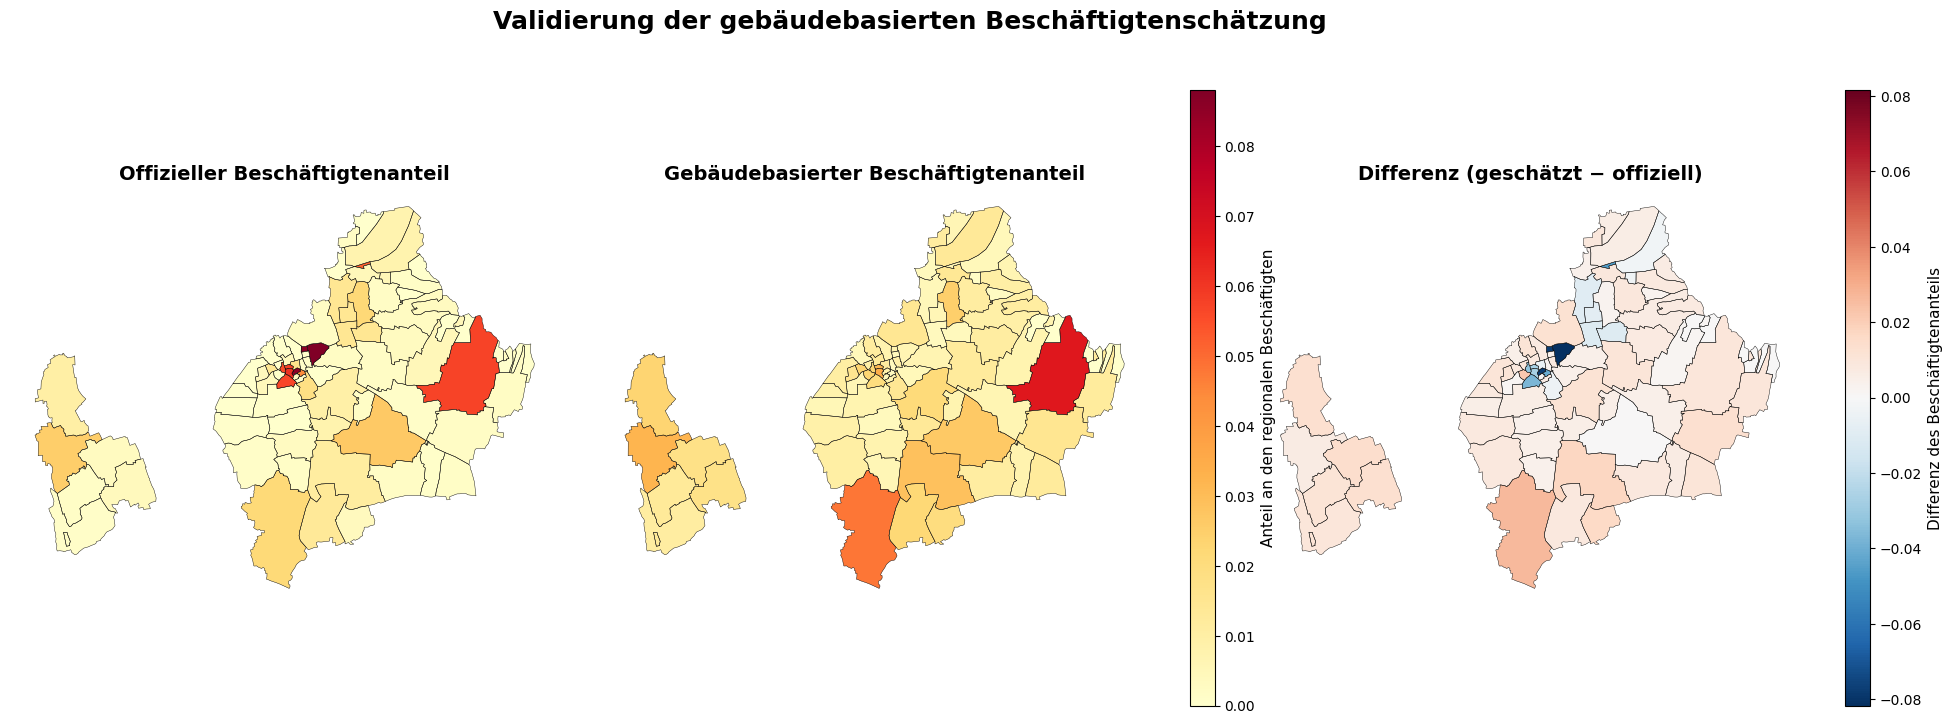

In [23]:
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec

# -----------------------------
# Differenz berechnen
# -----------------------------
gdf["share_difference"] = (
    gdf["estimated_workers_share"]
    - gdf["Workers_share"]
)

# -----------------------------
# Gemeinsame Farbskala für die ersten zwei Karten
# -----------------------------
vmin = min(
    gdf["Workers_share"].min(),
    gdf["estimated_workers_share"].min()
)

vmax = max(
    gdf["Workers_share"].max(),
    gdf["estimated_workers_share"].max()
)

# Differenzskala
max_diff = abs(gdf["share_difference"]).max()

# -----------------------------
# Abbildungslayout
# 3 Karten + 2 separate Farblegenden
# -----------------------------
fig = plt.figure(figsize=(24, 8))

gs = GridSpec(
    1,
    5,
    width_ratios=[1, 1, 0.045, 1, 0.045],
    wspace=0.12
)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
cax_share = fig.add_subplot(gs[2])

ax3 = fig.add_subplot(gs[3])
cax_diff = fig.add_subplot(gs[4])

# -----------------------------
# Offizieller Beschäftigtenanteil
# -----------------------------
gdf.plot(
    column="Workers_share",
    cmap="YlOrRd",
    vmin=vmin,
    vmax=vmax,
    linewidth=0,
    edgecolor="none",
    legend=False,
    ax=ax1
)

gdf.boundary.plot(
    ax=ax1,
    color="black",
    linewidth=0.30
)

ax1.set_title(
    "Offizieller Beschäftigtenanteil",
    fontsize=14,
    fontweight="bold"
)
ax1.axis("off")

# -----------------------------
# Gebäudebasierter Beschäftigtenanteil
# -----------------------------
gdf.plot(
    column="estimated_workers_share",
    cmap="YlOrRd",
    vmin=vmin,
    vmax=vmax,
    linewidth=0,
    edgecolor="none",
    legend=False,
    ax=ax2
)

gdf.boundary.plot(
    ax=ax2,
    color="black",
    linewidth=0.30
)

ax2.set_title(
    "Gebäudebasierter Beschäftigtenanteil",
    fontsize=14,
    fontweight="bold"
)
ax2.axis("off")

# -----------------------------
# Differenzkarte
# -----------------------------
gdf.plot(
    column="share_difference",
    cmap="RdBu_r",
    vmin=-max_diff,
    vmax=max_diff,
    linewidth=0,
    edgecolor="none",
    legend=False,
    ax=ax3
)

gdf.boundary.plot(
    ax=ax3,
    color="black",
    linewidth=0.30
)

ax3.set_title(
    "Differenz (geschätzt − offiziell)",
    fontsize=14,
    fontweight="bold"
)
ax3.axis("off")

# -----------------------------
# Farblegende für die ersten zwei Karten
# -----------------------------
sm_share = ScalarMappable(
    norm=Normalize(vmin=vmin, vmax=vmax),
    cmap="YlOrRd"
)
sm_share.set_array([])

cbar_share = fig.colorbar(
    sm_share,
    cax=cax_share
)

cbar_share.set_label(
    "Anteil an den regionalen Beschäftigten",
    fontsize=11
)

# -----------------------------
# Farblegende für die Differenzkarte
# -----------------------------
sm_diff = ScalarMappable(
    norm=Normalize(vmin=-max_diff, vmax=max_diff),
    cmap="RdBu_r"
)
sm_diff.set_array([])

cbar_diff = fig.colorbar(
    sm_diff,
    cax=cax_diff
)

cbar_diff.set_label(
    "Differenz des Beschäftigtenanteils",
    fontsize=11
)

# -----------------------------
# Haupttitel
# -----------------------------
fig.suptitle(
    "Validierung der gebäudebasierten Beschäftigtenschätzung",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

plt.show()

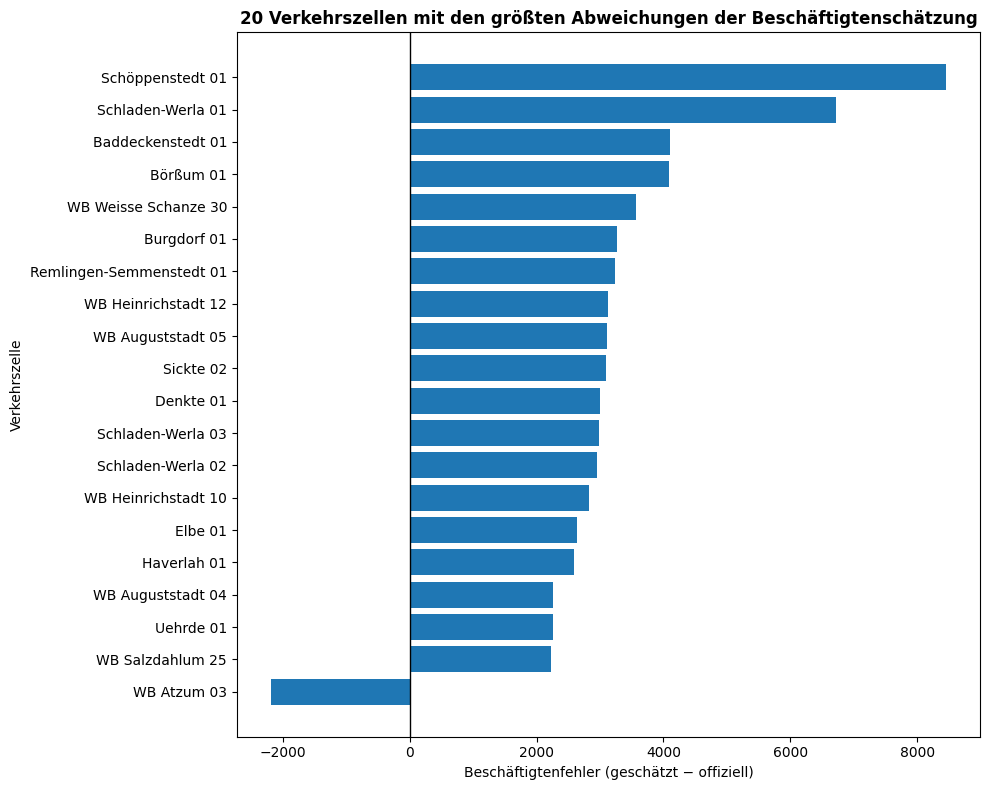

In [24]:
import matplotlib.pyplot as plt

# -----------------------------
# Fehler berechnen
# -----------------------------
gdf["worker_error"] = (
    gdf["estimated_workers_taz"] - gdf["Workers"]
)

gdf["abs_worker_error"] = gdf["worker_error"].abs()

# -----------------------------
# Top 20 Fehler
# -----------------------------
top_errors = (
    gdf
    .nlargest(20, "abs_worker_error")
    .sort_values("worker_error")
)

# -----------------------------
# Diagramm
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    top_errors["Region_Name"],
    top_errors["worker_error"]
)

ax.axvline(
    0,
    linewidth=1,
    color="black"
)

# -----------------------------
# Beschriftungen
# -----------------------------
ax.set_xlabel(
    "Beschäftigtenfehler (geschätzt − offiziell)"
)

ax.set_ylabel(
    "Verkehrszelle"
)

ax.set_title(
    "20 Verkehrszellen mit den größten Abweichungen der Beschäftigtenschätzung",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

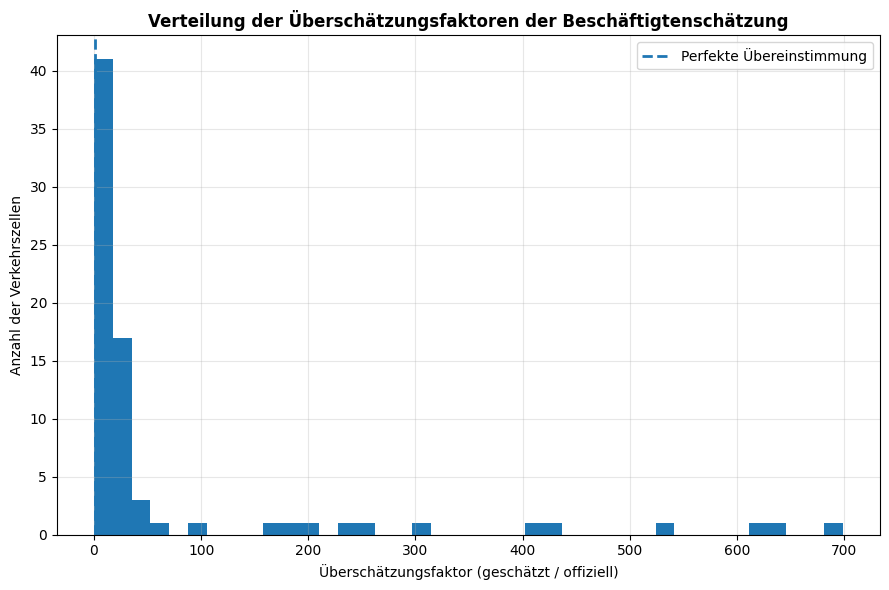

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Überschätzungsfaktor berechnen
# -----------------------------
gdf["overestimation_factor"] = np.where(
    gdf["Workers"] > 0,
    gdf["estimated_workers_taz"] / gdf["Workers"],
    np.nan
)

factor_df = gdf[
    gdf["overestimation_factor"]
    .replace([np.inf, -np.inf], np.nan)
    .notna()
].copy()

# -----------------------------
# Histogramm
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 6))

ax.hist(
    factor_df["overestimation_factor"],
    bins=40
)

ax.axvline(
    1,
    linestyle="--",
    linewidth=2,
    label="Perfekte Übereinstimmung"
)

# -----------------------------
# Beschriftungen
# -----------------------------
ax.set_xlabel(
    "Überschätzungsfaktor (geschätzt / offiziell)"
)

ax.set_ylabel(
    "Anzahl der Verkehrszellen"
)

ax.set_title(
    "Verteilung der Überschätzungsfaktoren der Beschäftigtenschätzung",
    fontweight="bold"
)

ax.legend()

ax.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

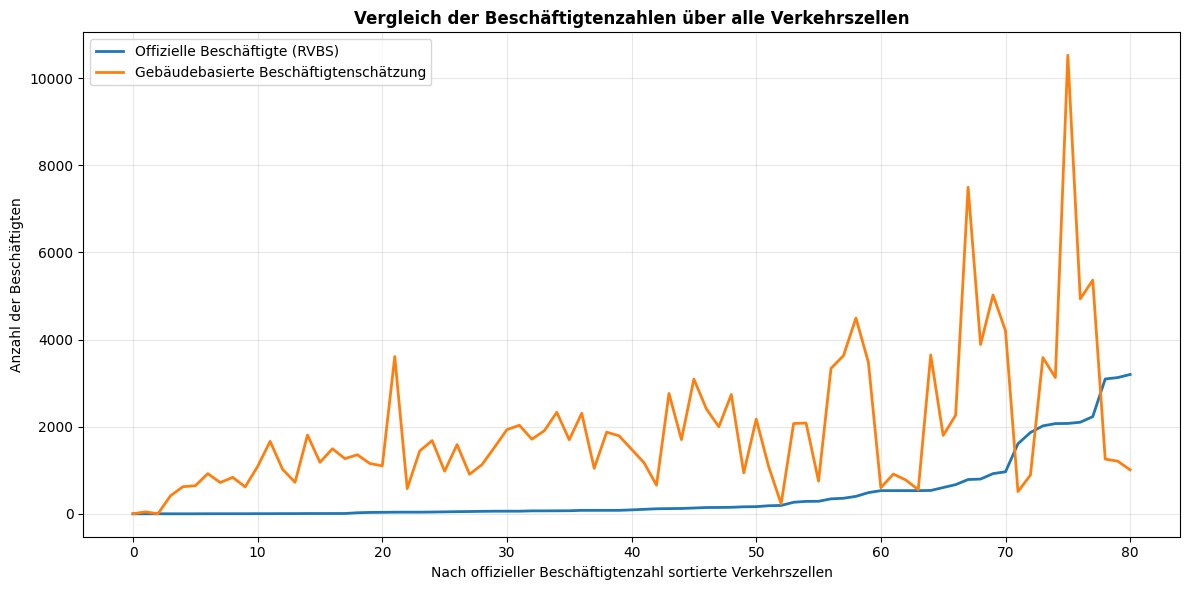

In [26]:
import matplotlib.pyplot as plt

# -----------------------------
# Nach offizieller Beschäftigtenzahl sortieren
# -----------------------------
rank_df = gdf.sort_values(
    "Workers"
).reset_index(drop=True)

# -----------------------------
# Diagramm
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    rank_df.index,
    rank_df["Workers"],
    label="Offizielle Beschäftigte (RVBS)",
    linewidth=2
)

ax.plot(
    rank_df.index,
    rank_df["estimated_workers_taz"],
    label="Gebäudebasierte Beschäftigtenschätzung",
    linewidth=2
)

# -----------------------------
# Beschriftungen
# -----------------------------
ax.set_xlabel(
    "Nach offizieller Beschäftigtenzahl sortierte Verkehrszellen"
)

ax.set_ylabel(
    "Anzahl der Beschäftigten"
)

ax.set_title(
    "Vergleich der Beschäftigtenzahlen über alle Verkehrszellen",
    fontweight="bold"
)

ax.legend()

ax.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()